# Librerías

In [1]:
import pandas as pd 
import math
import seaborn as sns
import requests
import ast
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from pandarallel import pandarallel

pandarallel.initialize(progress_bar=True) 
tqdm.pandas()

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [2]:
from src.process_results.sorce_verification import url_exists
from src.process_results.source_identification import classify_link_peer_review, unknown_breakdown, refine_unknowns_df

# Constantes

In [3]:
PATH = 'data/'
BATCH_SIZE = 500

# Lectura de datos

In [10]:
df = pd.read_csv(PATH + 'results_gemini.csv')

# Procesamiento y exploeación

In [11]:
df["references"] = df.references.apply(
    lambda x: str(x).replace('[', '').replace(']', '').split(','))

<Axes: >

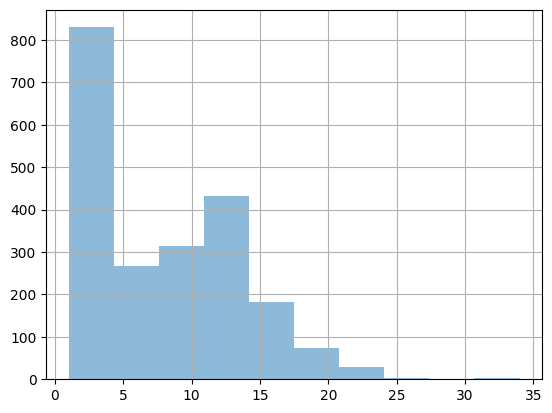

In [12]:
df['len_references'] = df['references'].apply(lambda x: len(x))
df['len_references'].hist(alpha = 0.5)

# Sacar links reales

In [30]:
import requests
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
import threading

# 1) Session "thread-local" (una por hilo)
_thread_local = threading.local()

def get_session():
    if not hasattr(_thread_local, "session"):
        s = requests.Session()
        # opcional: headers/UA
        s.headers.update({"User-Agent": "Mozilla/5.0"})
        _thread_local.session = s
    return _thread_local.session

def limpiar_url(url: str) -> str:
    return url.replace('"', "").replace("'", "").strip()

def obtener_url_real(url: str) -> str:
    try:
        s = get_session()
        r = s.head(url, allow_redirects=True, timeout=5)
        return r.url
    except requests.RequestException as e:
        return f"Error: {e.__class__.__name__}: {e}"

# 2) paraleliza *dentro* de cada lista
def obtener_urls(list_url, max_workers=32):
    urls = [limpiar_url(u) for u in list_url]
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        return list(ex.map(obtener_url_real, urls))

# 3) apply con progress a nivel fila
def apply_obtener_urls_con_progress(df, col="references", max_workers_urls=32):
    out = []
    for lst in tqdm(df[col].tolist(), total=len(df), desc="Filas"):
        out.append(obtener_urls(lst, max_workers=max_workers_urls))
    return out

# uso:
df["references_real"] = apply_obtener_urls_con_progress(df, col="references", max_workers_urls=32)

Filas:   0%|          | 0/2135 [00:00<?, ?it/s]

In [31]:
df['references_real'].iloc[0]

['https://papers.neurips.cc/paper_files/paper/2022/file/d3222559698f41247261b7a6c2bbaedc-Paper-Conference.pdf',
 'https://machinesgonewrong.com/fairness/',
 'https://arxiv.org/abs/2007.06024',
 'http://fitelson.org/primer.pdf',
 'https://www.researchgate.net/publication/325748511_Inherent_Trade-Offs_in_Algorithmic_Fairness',
 'https://medium.com/@afiori_78621/the-fairness-accuracy-tradeoff-af71d5d0c38a',
 'https://anderson-review.ucla.edu/the-trade-off-between-fairness-and-accuracy-in-algorithm-design/',
 'https://www.econstor.eu/bitstream/10419/238032/1/Janssen-Sadowski.pdf',
 'https://arxiv.org/abs/2209.13012',
 'https://www.researchgate.net/publication/363889138_Survey_on_Fairness_Notions_and_Related_Tensions',
 'https://www.semanticscholar.org/paper/Mathematical-Notions-vs.-Human-Perception-of-A-to-Srivastava-Heidari/784c51d2a4f51d67219bef617cce40102bb513e7',
 'https://pmc.ncbi.nlm.nih.gov/articles/PMC8913820/',
 'https://cacm.acm.org/research/what-should-we-do-when-our-ideas-of-fa

In [32]:
df.to_csv(PATH + 'results_gemini_links.csv', index = None) 

# Verificar links reales

## Lectura de datos

In [6]:
results_gemini = pd.read_csv(PATH + "results_gemini_links.csv")

## Verificar

In [7]:
results_gemini["references_real"] = results_gemini["references_real"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [8]:
results_gemini_links = results_gemini.explode('references_real')[['prompt', 'result', 'references_real']]

In [14]:
output_path = PATH + "processed/gemini_url_checks_progress.csv"

# Si quieres retomar desde donde quedaste (por si se interrumpe)
try:
    already_done = pd.read_csv(output_path)
    start_idx = len(already_done)
    print(f"Retomando desde fila {start_idx}")
except FileNotFoundError:
    already_done = None
    start_idx = 0

df_to_process = results_gemini_links.iloc[start_idx:].copy()
total_batches = math.ceil(len(df_to_process) / BATCH_SIZE)

for batch_num, batch_start in enumerate(range(0, len(df_to_process), BATCH_SIZE)):
    batch = df_to_process.iloc[batch_start : batch_start + BATCH_SIZE].copy()

    batch["url_check"] = batch["references_real"].progress_apply(url_exists)

    # Primera vez: escribe con header. El resto: append sin header
    is_first_write = (batch_num == 0 and already_done is None)
    batch.to_csv(output_path, mode="w" if is_first_write else "a",
                 header=is_first_write, index=False)

    print(f"Batch {batch_num + 1}/{total_batches} guardado ({batch_start + len(batch)} filas totales)")

print("✅ Proceso completado")

  0%|          | 0/500 [00:00<?, ?it/s]

Batch 1/33 guardado (500 filas totales)


  0%|          | 0/500 [00:00<?, ?it/s]

Batch 2/33 guardado (1000 filas totales)


  0%|          | 0/500 [00:00<?, ?it/s]

...

Batch 31/33 guardado (15500 filas totales)


  0%|          | 0/500 [00:00<?, ?it/s]

Batch 32/33 guardado (16000 filas totales)


  0%|          | 0/129 [00:00<?, ?it/s]

Batch 33/33 guardado (16129 filas totales)
✅ Proceso completado


## Procesamiento extra

In [8]:
output_path = PATH + "processed/gemini_url_checks_progress.csv"

df = pd.read_csv(output_path)
df['url_check'] = df['url_check'].apply(lambda x: ast.literal_eval(x))


In [10]:
def procesar_otras_status(url_check):
    url_check_copy = url_check.copy()
    if url_check['status_code'] in [200, 402, 403, 406, 502, 503, 405]:
        url_check_copy['exists'] = True
    return url_check_copy

df['url_check'] = df['url_check'].apply(procesar_otras_status)

df['url_check'].apply(lambda x: x['exists']).value_counts()

url_check
True     14817
False     1312
Name: count, dtype: int64

In [11]:
df['url_check'].apply(lambda x: x['exists']).value_counts(True)

url_check
True     0.918656
False    0.081344
Name: proportion, dtype: float64

## Clasificar

In [12]:
df_gemini = pd.read_csv(output_path)

In [13]:
df_gemini["url_check"] = df_gemini["url_check"].apply(
    lambda x: ast.literal_eval(x)
)

In [ ]:
# Viejo
df_gemini = df_gemini[df_gemini["url_check"].apply(lambda x: x["exists"])]
df_gemini["url_labels"] = df_gemini["references_real"].apply(
    lambda u: [{**classify_link_peer_review(u), "url": u}] 
)

# 2. Ver cuántos quedaron unknown y por qué
stats = unknown_breakdown(df_gemini, col_url_labels="url_labels")
print(stats["unknown_rate"])          # ej: 0.35
print(stats["unknown_reason_dist"])   # no_doi: 60%, doi_not_resolved: 40%
# 3. Refinar los unknowns
df = refine_unknowns_df(df_gemini, col_url_labels="url_labels")
unknown_breakdown(df_gemini, col_url_labels="url_labels")
df.url_labels.apply(lambda x: x[0]["label"]).value_counts()

0.9122
                         reason  count     pct
0                        no_doi  10648  0.9930
1              doi_not_resolved     68  0.0063
2  crossref_type_posted-content      7  0.0007


url_labels
unknown         6873
not_refereed    3149
refereed        1733
Name: count, dtype: int64

In [15]:
from src.process_results.classify_urls import classify_url, process_urls                    

In [25]:
df_gemini.url_check.iloc[0]

{'url': 'https://papers.neurips.cc/paper_files/paper/2022/file/d3222559698f41247261b7a6c2bbaedc-Paper-Conference.pdf',
 'exists': True,
 'status_code': 200,
 'final_url': 'https://papers.neurips.cc/paper_files/paper/2022/file/d3222559698f41247261b7a6c2bbaedc-Paper-Conference.pdf',
 'error': None}

In [26]:
df_gemini_revision = df_gemini[df_gemini.url_check.apply(lambda x: x['exists'])]
df_gemini_revision['clasificacion'] = df_gemini_revision['references_real'].progress_apply(
    classify_url)

  0%|          | 0/11755 [00:00<?, ?it/s]

In [28]:
df_gemini_revision['clasificacion'].iloc[0]

{'url': 'https://papers.neurips.cc/paper_files/paper/2022/file/d3222559698f41247261b7a6c2bbaedc-Paper-Conference.pdf',
 'peer_reviewed': 'sí',
 'confianza': 'baja',
 'razon': "Heurística: patrón '/paper[s]?/' en URL",
 'doi': ''}

In [30]:
# Nuevo
df_gemini_revision['clasificacion'].apply(lambda x: x['peer_reviewed']).value_counts()

clasificacion
no    10280
sí     1475
Name: count, dtype: int64

In [31]:
df_gemini_revision['clasificacion'].apply(lambda x: x['confianza']).value_counts()

clasificacion
baja     9897
alta     1816
media      42
Name: count, dtype: int64

## 